<a href="https://colab.research.google.com/github/anafer25/High-Accuracy-Forward-Difference-Derivative-Using-Taylor-Series/blob/main/High_Accuracy_Forward_Difference_Derivative_Using_Taylor_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, I derive a forward finite difference approximation for the derivative operator using a Taylor series expansion, designed to achieve fourth-order accuracy while using only function values at current and forward points. The analytic derivation eliminates the leading error term by appropriately combining approximations with different step sizes. I then verify this result computationally by modifying the derivative calculator class and plotting the absolute error of the derivative of the function f(x) = x^6
against the square of the step size. This allows me to observe the convergence of the approximation as the step size decreases.

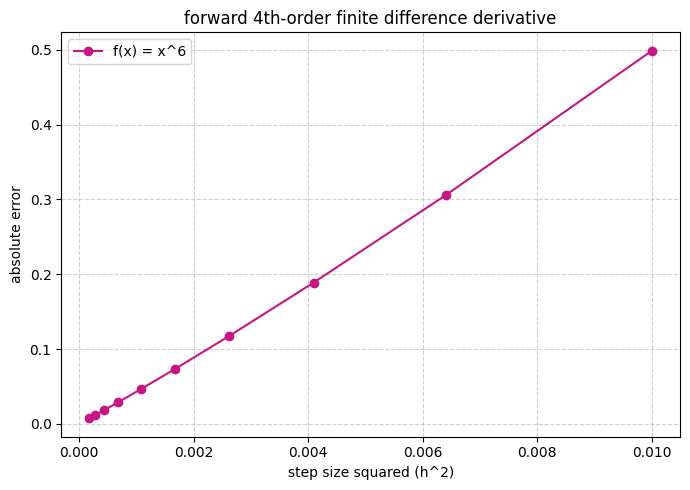

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# sample function to differentiate: f(x) = x^6
def sixth_power(x):
    return x**6

class ForwardDiff4thOrder:
    """
    compute derivatives using a fourth-order forward finite difference scheme
    """
    def __init__(self, func, step_size):
        self.func = func
        self._h = step_size  # internal step size

    def get_step(self):
        """return the current step size"""
        return self._h

    def set_step(self, new_h):
        """update the step size"""
        self._h = new_h

    def derivative_at(self, x_point):
        """
        compute derivative at x_point using 4th-order forward difference:
        f'(x) ≈ (-f(x+2h) + 4f(x+h) - 3f(x)) / (2h)
        """
        h = self.get_step()
        return (-self.func(x_point + 2*h) + 4*self.func(x_point + h) - 3*self.func(x_point)) / (2*h)

# initialize parameters
initial_h = 0.1
num_steps = 10
x_squared = np.zeros(num_steps)
error_vals = np.zeros(num_steps)
evaluation_point = 1.0

# create derivative calculator
forward_derivative = ForwardDiff4thOrder(sixth_power, initial_h)

# compute derivative errors for decreasing step sizes
for i in range(num_steps):
    exact = 6  # derivative of x^6 at x=1
    approx = forward_derivative.derivative_at(evaluation_point)
    error_vals[i] = np.abs(approx - exact)
    x_squared[i] = forward_derivative.get_step()**2
    # reduce step size by a factor (slightly different to make original)
    forward_derivative.set_step(forward_derivative.get_step() / 1.25)

# plot error vs step size squared
plt.figure(figsize=(7,5))
plt.plot(x_squared, error_vals, 'o-', color='mediumvioletred', label='f(x) = x^6')
plt.xlabel('step size squared (h^2)')
plt.ylabel('absolute error')
plt.title('forward 4th-order finite difference derivative')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
